# 🍕 Pizza Company Data Visualisation 
**Mid Exam | Data Visualisation**  

Name : Teuku Muhammad Rayhan Arrafi

NIM : 031202400015


---

## Table of Contents
1. [Data Loading & Understanding](#1)
2. [Data Integration & Wrangling](#2)
3. [Customer Activity Analysis](#3)
4. [Order Behaviour Analysis](#4)
5. [Revenue Analysis](#5)
6. [Product Performance Analysis](#6)
7. [Sales Analysis](#7)

In [ ]:
# Import Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE = ['#E63946','#F4A261','#2A9D8F','#264653','#A8DADC','#457B9D']
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


In [ ]:
# Load Raw Datasets 
orders        = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
pizza_types   = pd.read_csv('pizza_types.csv', encoding='latin1')  # ⚠ special characters
pizzas        = pd.read_csv('pizzas.csv')

print('Datasets loaded:')
print(f'  orders        : {orders.shape}')
print(f'  order_details : {order_details.shape}')
print(f'  pizza_types   : {pizza_types.shape}')
print(f'  pizzas        : {pizzas.shape}')

Datasets loaded:
  orders        : (21350, 3)
  order_details : (48620, 4)
  pizza_types   : (32, 4)
  pizzas        : (96, 4)


### 1.1 Dataset Schemas

In [8]:
print('=== orders ===')
display(orders.head(3))
print(orders.dtypes)
print()

=== orders ===


,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28


order_id    int64
date          str
time          str
dtype: object



In [9]:
print('=== order_details ===')
display(order_details.head(3))
print(order_details.dtypes)

=== order_details ===


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1


order_details_id    int64
order_id            int64
pizza_id              str
quantity            int64
dtype: object


In [10]:
print('=== pizza_types ===')
display(pizza_types.head(3))
print(pizza_types.dtypes)

=== pizza_types ===


,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."


pizza_type_id    str
name             str
category         str
ingredients      str
dtype: object


In [11]:
print('=== pizzas ===')
display(pizzas.head(3))
print(pizzas.dtypes)

=== pizzas ===


,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75


pizza_id             str
pizza_type_id        str
size                 str
price            float64
dtype: object


### 1.2 Missing Values Check

In [12]:
for name, df_raw in [('orders', orders), ('order_details', order_details),
                     ('pizza_types', pizza_types), ('pizzas', pizzas)]:
    nulls = df_raw.isnull().sum().sum()
    dups  = df_raw.duplicated().sum()
    print(f'{name:15s} → missing: {nulls}, duplicates: {dups} ✅')

orders          → missing: 0, duplicates: 0 ✅
order_details   → missing: 0, duplicates: 0 ✅
pizza_types     → missing: 0, duplicates: 0 ✅
pizzas          → missing: 0, duplicates: 0 ✅


**Insight:** Semua dataset bersih tidak ada missing values maupun baris duplikat. Data siap untuk diintegrasikan.

### 1.3 Understanding Each Table (Visualisation)

Sebelum merge, kita visualisasikan distribusi kolom-kolom kunci dari masing-masing tabel.

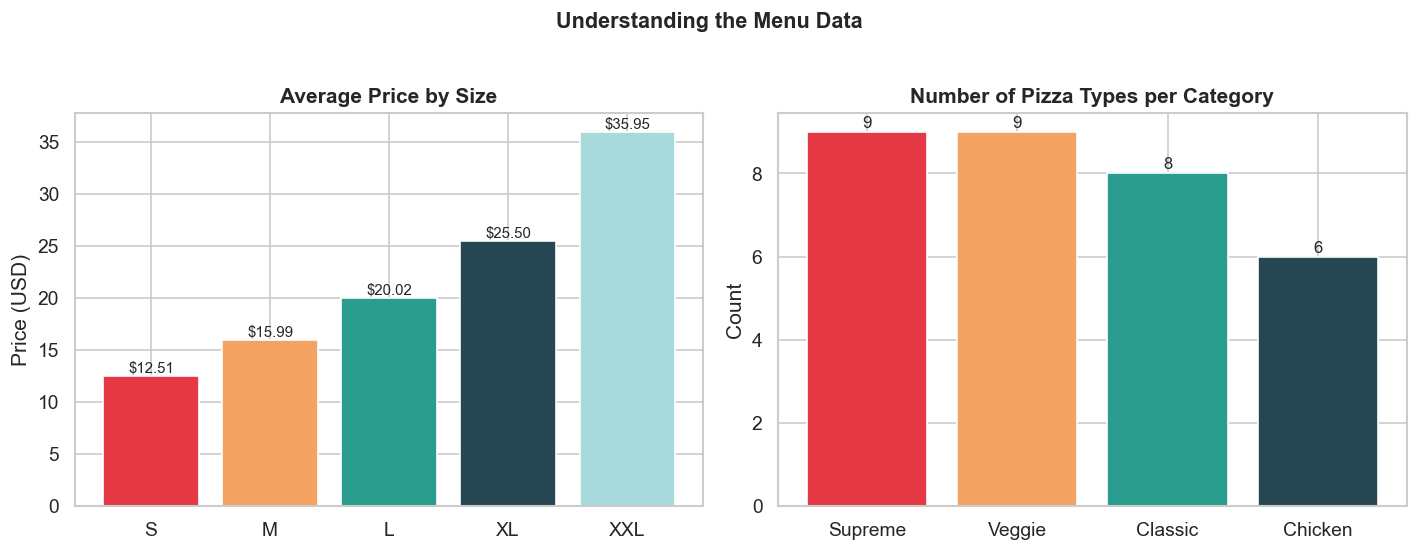

In [ ]:
# Price distribution per size (pizzas table) 
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

size_order = ['S', 'M', 'L', 'XL', 'XXL']
price_by_size = pizzas.groupby('size')['price'].mean().reindex(size_order)
axes[0].bar(price_by_size.index, price_by_size.values, color=PALETTE[:5], edgecolor='white')
axes[0].set_title('Average Price by Size', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
for i, v in enumerate(price_by_size.values):
    axes[0].text(i, v + 0.3, f'${v:.2f}', ha='center', fontsize=9)

# Count of pizza types per category
cat_count = pizza_types['category'].value_counts()
axes[1].bar(cat_count.index, cat_count.values, color=PALETTE[:4], edgecolor='white')
axes[1].set_title('Number of Pizza Types per Category', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(cat_count.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=10)

plt.suptitle('Understanding the Menu Data', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

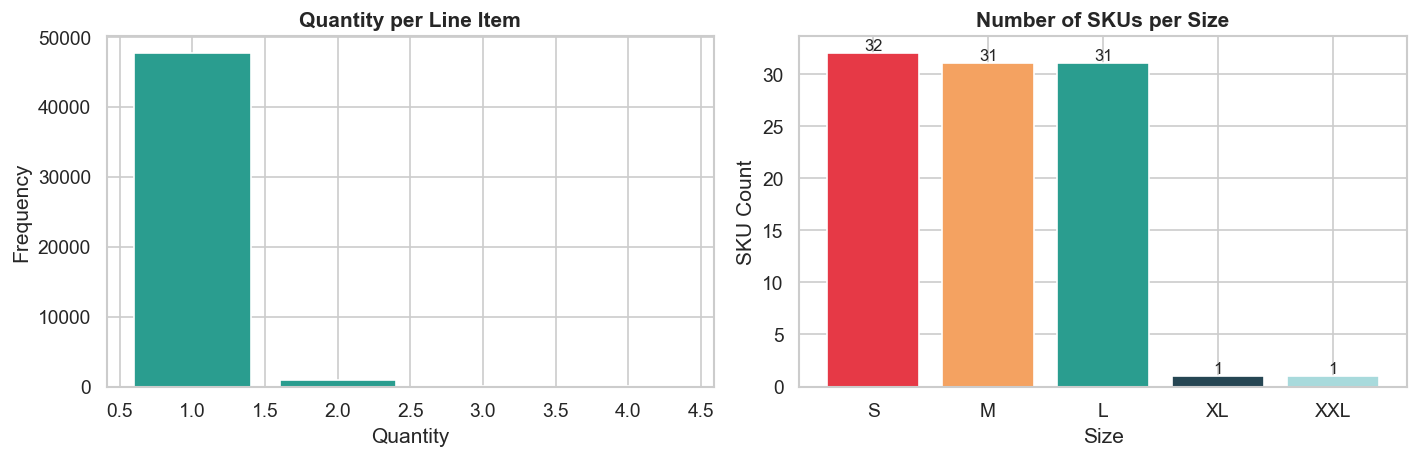

In [ ]:
# Orders: quantity distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

qty_counts = order_details['quantity'].value_counts().sort_index()
axes[0].bar(qty_counts.index, qty_counts.values, color=PALETTE[2], edgecolor='white')
axes[0].set_title('Quantity per Line Item', fontweight='bold')
axes[0].set_xlabel('Quantity'); axes[0].set_ylabel('Frequency')

# pizzas table: SKU count per size
sku_size = pizzas['size'].value_counts().reindex(size_order)
axes[1].bar(sku_size.index, sku_size.values, color=PALETTE[:5], edgecolor='white')
axes[1].set_title('Number of SKUs per Size', fontweight='bold')
axes[1].set_xlabel('Size'); axes[1].set_ylabel('SKU Count')
for i, v in enumerate(sku_size.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Insight:**
- Menu terdiri dari **32 jenis pizza** dengan **96 SKU** (tiap jenis × 5 ukuran)
- Kategori **Supreme memiliki paling banyak varian** (9 jenis), diikuti Chicken (6), Classic (8), Veggie (9)
- Harga rata-rata naik signifikan dari ukuran S ke L, sementara XL dan XXL memiliki selisih harga yang lebih besar
- Hampir semua line-item order berjumlah quantity = 1, artinya pelanggan jarang memesan lebih dari 1 pizza yang sama sekaligus

---
## 2. Data Integration & Wrangling <a id='2'></a>

### 2.1 Entity Relationship

```
orders (order_id)
    └──< order_details (order_id, pizza_id)
              └──> pizzas (pizza_id, pizza_type_id)
                       └──> pizza_types (pizza_type_id)
```

In [ ]:
# Step 1: Merge order_details + pizzas 
df = order_details.merge(pizzas, on='pizza_id')
print(f'After merge order_details + pizzas : {df.shape}')

# Step 2: Merge + pizza_types
df = df.merge(pizza_types, on='pizza_type_id')
print(f'After merge + pizza_types          : {df.shape}')

# Step 3: Merge + orders
df = df.merge(orders, on='order_id')
print(f'After merge + orders               : {df.shape}')

display(df.head())

After merge order_details + pizzas : (48620, 7)
After merge + pizza_types          : (48620, 10)
After merge + orders               : (48620, 12)


,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,date,time
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01,11:38:36
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01,11:57:40
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01,11:57:40
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,11:57:40
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",2015-01-01,11:57:40


### 2.2 Feature Engineering

In [16]:
# ── Type conversion & derived features ───────────────────────────────────────
df['date']        = pd.to_datetime(df['date'])
df['time']        = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time
df['revenue']     = df['quantity'] * df['price']        # line-item revenue

# Time-based features
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%b')
df['quarter']     = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.day_name()
df['week']        = df['date'].dt.isocalendar().week.astype(int)
df['hour']        = pd.to_datetime(df['time'].astype(str), format='%H:%M:%S').dt.hour

print('Final column list:')
print(df.columns.tolist())
print(f'\nDate range : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Total rows : {len(df):,}')

Final column list:
['order_details_id', 'order_id', 'pizza_id', 'quantity', 'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients', 'date', 'time', 'revenue', 'year', 'month', 'month_name', 'quarter', 'day_of_week', 'week', 'hour']

Date range : 2015-01-01 → 2015-12-31
Total rows : 48,620


### 2.3 Final Data Quality Check

In [17]:
print('=== Null Values ===')
print(df.isnull().sum())
print(f'\nDuplicates : {df.duplicated().sum()}')
print(f'Negative revenue : {(df["revenue"] < 0).sum()}')
print(f'\nData types:')
print(df.dtypes)

=== Null Values ===
order_details_id    0
order_id            0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
date                0
time                0
revenue             0
year                0
month               0
month_name          0
quarter             0
day_of_week         0
week                0
hour                0
dtype: int64

Duplicates : 0
Negative revenue : 0

Data types:
order_details_id             int64
order_id                     int64
pizza_id                       str
quantity                     int64
pizza_type_id                  str
size                           str
price                      float64
name                           str
category                       str
ingredients                    str
date                datetime64[us]
time                        object
revenue                    float64
year                  

In [ ]:
# Statistical summary
display(df[['quantity','price','revenue']].describe().round(2))

,quantity,price,revenue
count,48620.00,48620.00,48620.00
mean,1.02,16.49,16.82
std,0.14,3.62,4.44
min,1.00,9.75,9.75
25%,1.00,12.75,12.75
50%,1.00,16.50,16.50
75%,1.00,20.25,20.50
max,4.00,35.95,83.00


### 2.4 Visualisasi Wrangling: Distribusi Data Hasil Integrasi

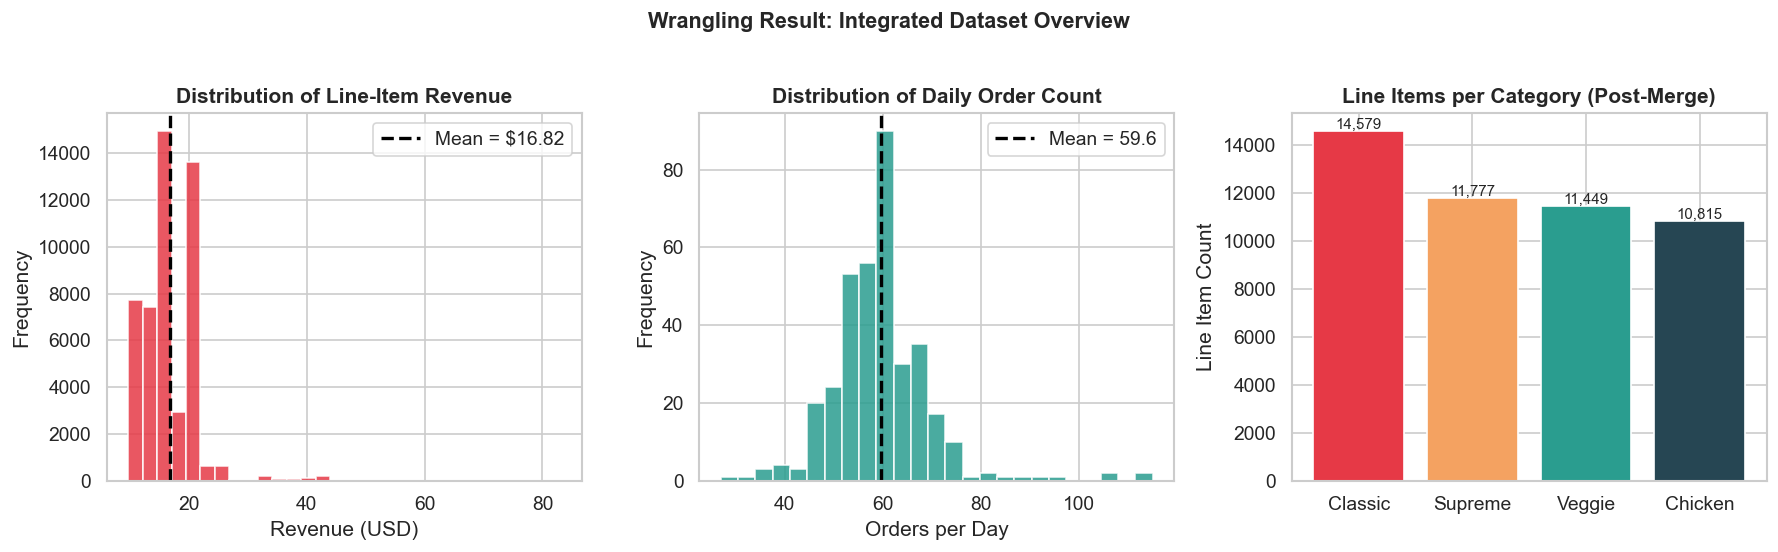

In [ ]:
# Visualise merged data completeness & distribution ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Revenue distribution
axes[0].hist(df['revenue'], bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Line-Item Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (USD)'); axes[0].set_ylabel('Frequency')
axes[0].axvline(df['revenue'].mean(), color='black', lw=2, linestyle='--',
                label=f'Mean = ${df["revenue"].mean():.2f}')
axes[0].legend()

# 2. Number of orders per day (distribution)
orders_per_day = df.groupby('date')['order_id'].nunique()
axes[1].hist(orders_per_day, bins=25, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Daily Order Count', fontweight='bold')
axes[1].set_xlabel('Orders per Day'); axes[1].set_ylabel('Frequency')
axes[1].axvline(orders_per_day.mean(), color='black', lw=2, linestyle='--',
                label=f'Mean = {orders_per_day.mean():.1f}')
axes[1].legend()

# 3. Total records per category after merge
cat_records = df['category'].value_counts()
axes[2].bar(cat_records.index, cat_records.values, color=PALETTE[:4], edgecolor='white')
axes[2].set_title('Line Items per Category (Post-Merge)', fontweight='bold')
axes[2].set_ylabel('Line Item Count')
for i, v in enumerate(cat_records.values):
    axes[2].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Wrangling Result: Integrated Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:**
- Distribusi revenue per line-item **right-skewed** mayoritas transaksi bernilai kecil (1 pizza standar), namun ada outlier transaksi besar (order grup)
- Distribusi order harian cukup **normal dan konsisten** di sekitar 59–60 order/hari
- Classic dan Supreme memiliki jumlah line-item terbanyak, mencerminkan popularitasnya

---
## 3. Customer Activity Analysis <a id='3'></a>

In [ ]:
# KPI Summary 
total_orders   = df['order_id'].nunique()
avg_per_day    = df.groupby('date')['order_id'].nunique().mean()
peak_month     = df.groupby('month_name')['order_id'].nunique().idxmax()

print(f'Total Orders (2015)     : {total_orders:,}')
print(f'Average Orders/Day      : {avg_per_day:.1f}')
print(f'Peak Month              : {peak_month}')

Total Orders (2015)     : 21,350
Average Orders/Day      : 59.6
Peak Month              : Jul


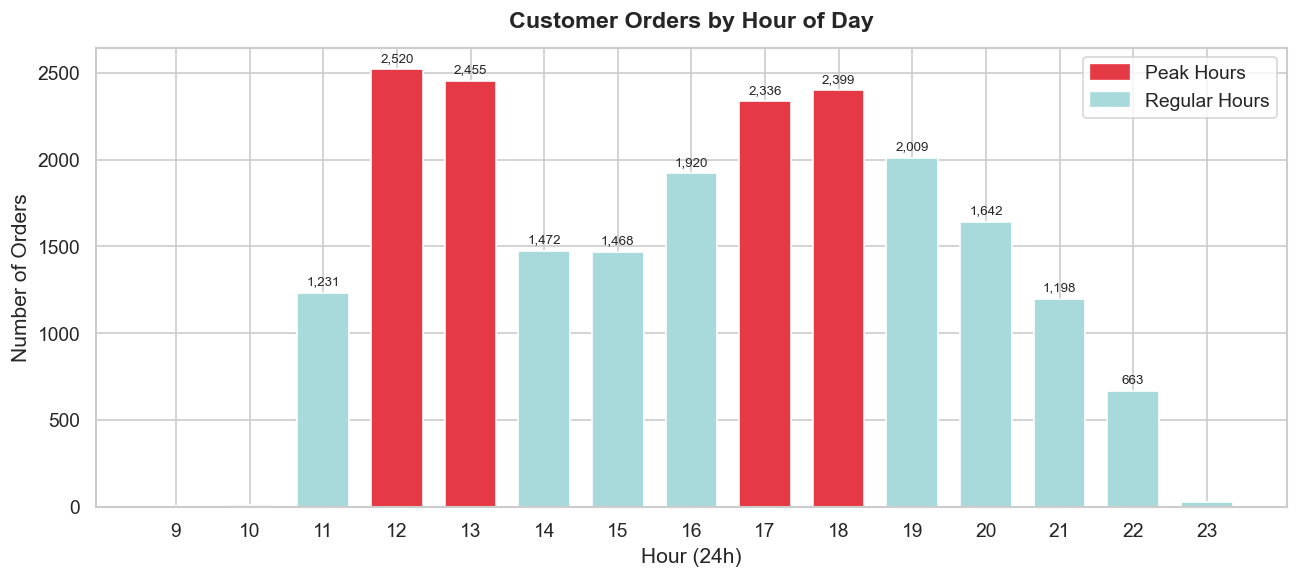

In [ ]:
# Chart: Orders by Hour 
fig, ax = plt.subplots(figsize=(11, 5))

by_hour = df.groupby('hour')['order_id'].nunique()
colors_h = [PALETTE[0] if h in [12, 13, 17, 18] else PALETTE[4] for h in by_hour.index]
bars = ax.bar(by_hour.index, by_hour.values, color=colors_h, edgecolor='white', width=0.7)

ax.set_title('Customer Orders by Hour of Day', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour (24h)'); ax.set_ylabel('Number of Orders')
ax.set_xticks(by_hour.index)
for bar in bars:
    h = bar.get_height()
    if h > 200:
        ax.text(bar.get_x() + bar.get_width()/2, h + 30, f'{int(h):,}',
                ha='center', va='bottom', fontsize=8)

ax.legend(handles=[plt.Rectangle((0,0),1,1,color=PALETTE[0]),
                   plt.Rectangle((0,0),1,1,color=PALETTE[4])],
          labels=['Peak Hours','Regular Hours'])
plt.tight_layout()
plt.show()

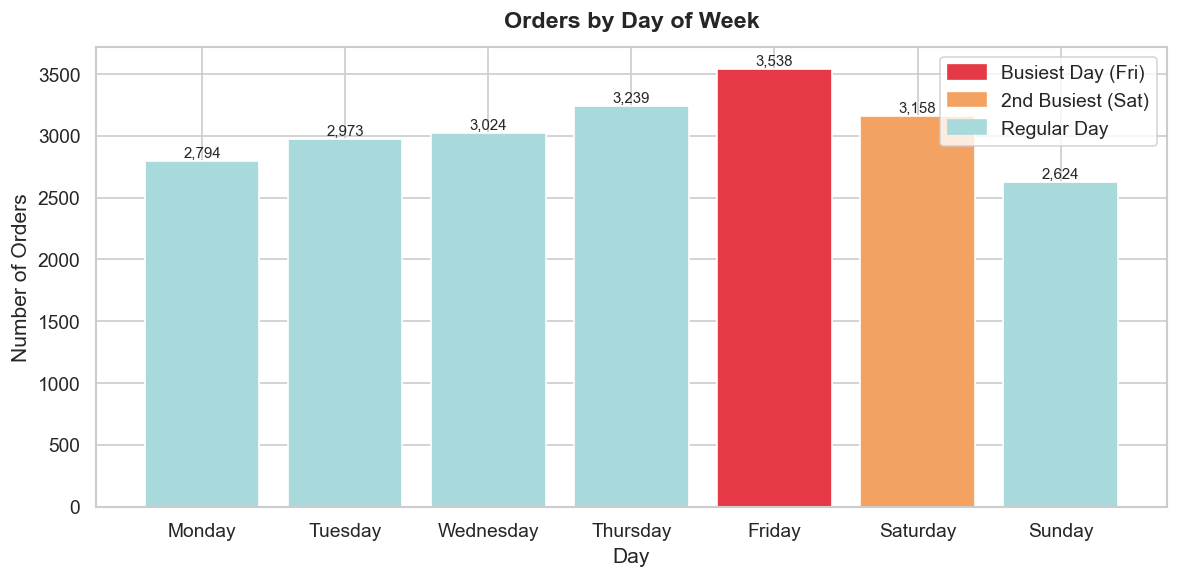

In [ ]:
# Chart: Orders by Day of Week 
fig, ax = plt.subplots(figsize=(10, 5))

day_order_list = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_day = df.groupby('day_of_week')['order_id'].nunique().reindex(day_order_list)
colors_d = [PALETTE[0] if d == 'Friday' else
            PALETTE[1] if d == 'Saturday' else PALETTE[4] for d in day_order_list]

ax.bar(by_day.index, by_day.values, color=colors_d, edgecolor='white')
ax.set_title('Orders by Day of Week', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Day'); ax.set_ylabel('Number of Orders')
for i, (d, v) in enumerate(zip(by_day.index, by_day.values)):
    ax.text(i, v + 30, f'{int(v):,}', ha='center', fontsize=9)

ax.legend(handles=[plt.Rectangle((0,0),1,1,color=PALETTE[0]),
                   plt.Rectangle((0,0),1,1,color=PALETTE[1]),
                   plt.Rectangle((0,0),1,1,color=PALETTE[4])],
          labels=['Busiest Day (Fri)','2nd Busiest (Sat)','Regular Day'])
plt.tight_layout()
plt.show()

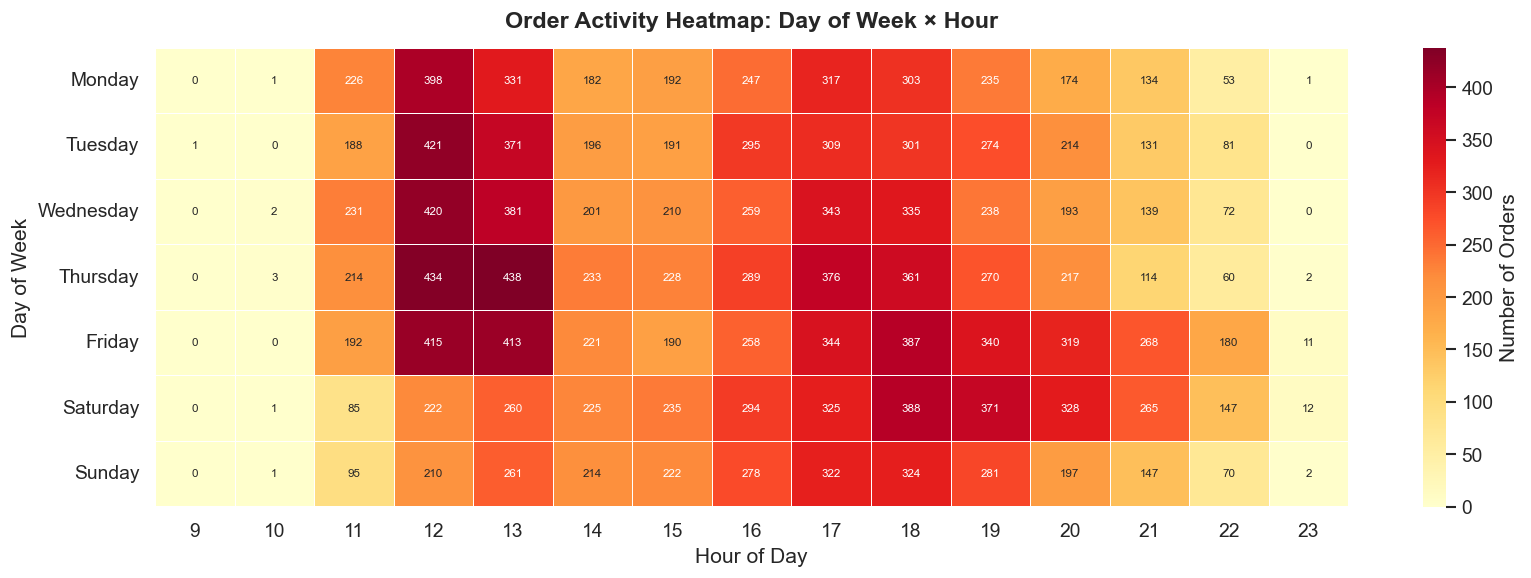

In [ ]:
# Chart: Heatmap Day × Hour 
fig, ax = plt.subplots(figsize=(14, 5))

pivot = df.groupby(['day_of_week','hour'])['order_id'].nunique().unstack(fill_value=0)
pivot = pivot.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Number of Orders'},
            annot=True, fmt='d', annot_kws={'size': 7})
ax.set_title('Order Activity Heatmap: Day of Week × Hour', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

### Insights Customer Activity

| Temuan | Detail |
|---|---|
| **Dua puncak harian** | Lunch peak jam **12:00 (2,520 orders)** dan dinner peak jam **17:00–18:00 (~2,336–2,399 orders)** |
| **Hari tersibuk** | **Jumat** dengan 3,538 orders — 34.6% lebih tinggi dari hari paling sepi (Minggu: 2,624) |
| **Hari paling sepi** | **Minggu dan Senin** — potensi untuk promo khusus |
| **Zona panas** | Jumat dan Sabtu malam adalah waktu tersibuk dalam seminggu |
| **Jam paling sepi** | Sebelum jam 11 dan setelah jam 22 — cocok untuk maintenance atau restocking |

---
## 4. Order Behaviour Analysis <a id='4'></a>

In [ ]:
# Order level aggregation 
order_agg = df.groupby('order_id').agg(
    total_items    = ('quantity', 'sum'),
    total_revenue  = ('revenue', 'sum'),
    distinct_pizzas= ('pizza_id', 'nunique')
).reset_index()

print('Order Summary Statistics:')
display(order_agg[['total_items','total_revenue','distinct_pizzas']].describe().round(2))

Order Summary Statistics:


,total_items,total_revenue,distinct_pizzas
count,21350.00,21350.00,21350.00
mean,2.32,38.31,2.28
std,1.83,30.65,1.71
min,1.00,9.75,1.00
25%,1.00,17.95,1.00
50%,2.00,32.50,2.00
75%,3.00,49.50,3.00
max,28.00,444.20,21.00


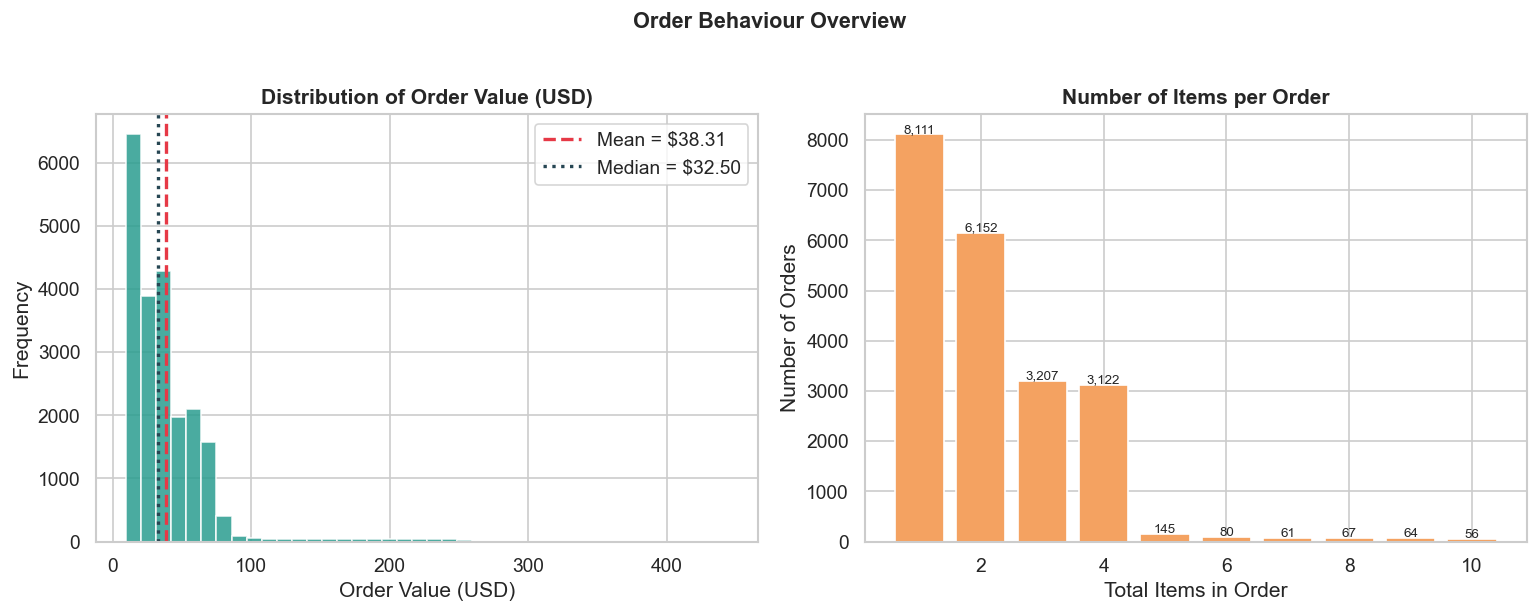

In [ ]:
# Chart: Distribution of Order Value 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram order value
axes[0].hist(order_agg['total_revenue'], bins=40, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[0].axvline(order_agg['total_revenue'].mean(), color=PALETTE[0], lw=2,
                linestyle='--', label=f'Mean = ${order_agg["total_revenue"].mean():.2f}')
axes[0].axvline(order_agg['total_revenue'].median(), color=PALETTE[3], lw=2,
                linestyle=':', label=f'Median = ${order_agg["total_revenue"].median():.2f}')
axes[0].set_title('Distribution of Order Value (USD)', fontweight='bold')
axes[0].set_xlabel('Order Value (USD)'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# Bar chart: items per order
items_count = order_agg['total_items'].value_counts().sort_index().head(10)
axes[1].bar(items_count.index, items_count.values, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Number of Items per Order', fontweight='bold')
axes[1].set_xlabel('Total Items in Order'); axes[1].set_ylabel('Number of Orders')
for i, (x, v) in enumerate(zip(items_count.index, items_count.values)):
    axes[1].text(x, v + 30, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Order Behaviour Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

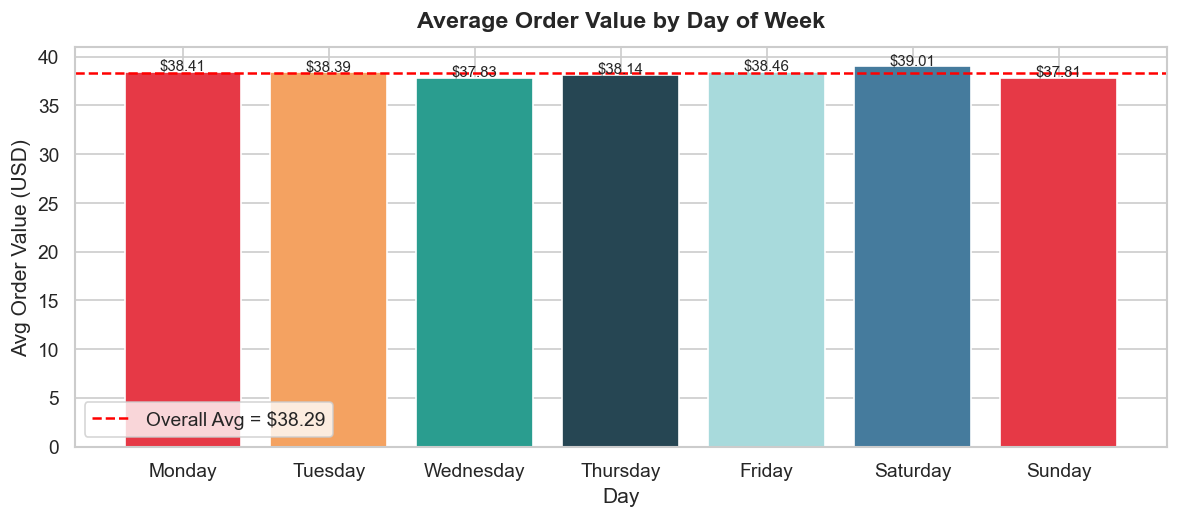

In [ ]:
# Chart: Average Order Value by Day
fig, ax = plt.subplots(figsize=(10, 4.5))

aov_day = df.merge(order_agg[['order_id','total_revenue']], on='order_id')\
            .drop_duplicates('order_id')\
            .groupby('day_of_week')['total_revenue'].mean().reindex(day_order_list)

ax.bar(aov_day.index, aov_day.values, color=PALETTE[:7], edgecolor='white')
ax.set_title('Average Order Value by Day of Week', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Day'); ax.set_ylabel('Avg Order Value (USD)')
ax.axhline(aov_day.mean(), color='red', lw=1.5, linestyle='--', label=f'Overall Avg = ${aov_day.mean():.2f}')
ax.legend()
for i, v in enumerate(aov_day.values):
    ax.text(i, v + 0.2, f'${v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Insights Order Behaviour

| Temuan | Detail |
|---|---|
| **Rata-rata order** | **\$38.31** per transaksi |
| **Item per order** | Rata-rata **2.32 item**, median 2 |
| **Distribusi skewed** | Mayoritas order bernilai \$10–\$50, tapi ada outlier hingga \$143 (order grup besar) |
| **Upsell opportunity** | 75% order hanya ≤ 3 item — ada ruang besar untuk upselling |
| **Order value stabil** | Average order value relatif konsisten sepanjang hari — tidak ada hari yang signifikan lebih mahal |

---
## 5. Revenue Analysis <a id='5'></a>

In [ ]:
# KPI
total_rev   = df['revenue'].sum()
monthly_rev = df.groupby('month')['revenue'].sum()

print(f'Total Revenue (2015)     : ${total_rev:,.2f}')
print(f'Average Monthly Revenue  : ${monthly_rev.mean():,.2f}')
print(f'Best Month               : {monthly_rev.idxmax()} (${monthly_rev.max():,.2f})')
print(f'Worst Month              : {monthly_rev.idxmin()} (${monthly_rev.min():,.2f})')

Total Revenue (2015)     : $817,860.05
Average Monthly Revenue  : $68,155.00
Best Month               : 7 ($72,557.90)
Worst Month              : 10 ($64,027.60)


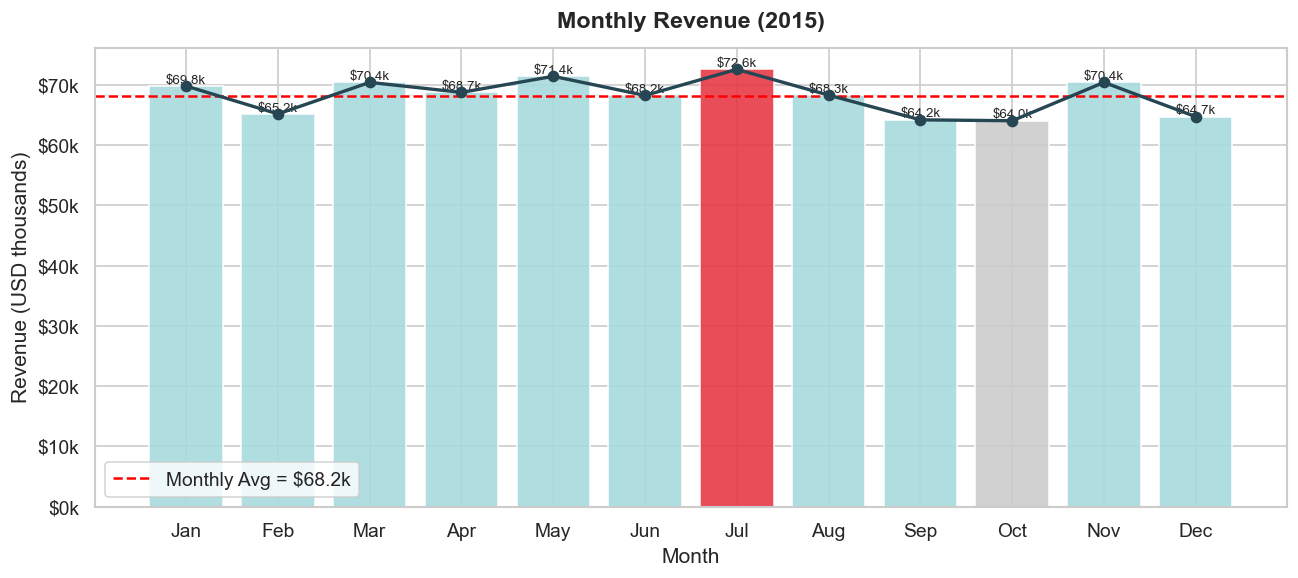

In [ ]:
# Chart: Monthly Revenue
fig, ax = plt.subplots(figsize=(11, 5))

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby(['month','month_name'])['revenue'].sum().reset_index().sort_values('month')
monthly['month_name'] = pd.Categorical(monthly['month_name'], categories=month_order, ordered=True)

bar_colors = [PALETTE[0] if r == monthly['revenue'].max() else
              '#cccccc' if r == monthly['revenue'].min() else PALETTE[4]
              for r in monthly['revenue']]

ax.bar(monthly['month_name'], monthly['revenue']/1000, color=bar_colors, edgecolor='white', alpha=0.9)
ax.plot(monthly['month_name'], monthly['revenue']/1000, 'o-', color=PALETTE[3], lw=2, ms=6, zorder=5)
ax.axhline(monthly['revenue'].mean()/1000, color='red', lw=1.5, linestyle='--',
           label=f'Monthly Avg = ${monthly["revenue"].mean()/1000:.1f}k')
ax.set_title('Monthly Revenue (2015)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (USD thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend()
for i, row in monthly.iterrows():
    ax.text(i, row['revenue']/1000 + 0.5, f'${row["revenue"]/1000:.1f}k',
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()

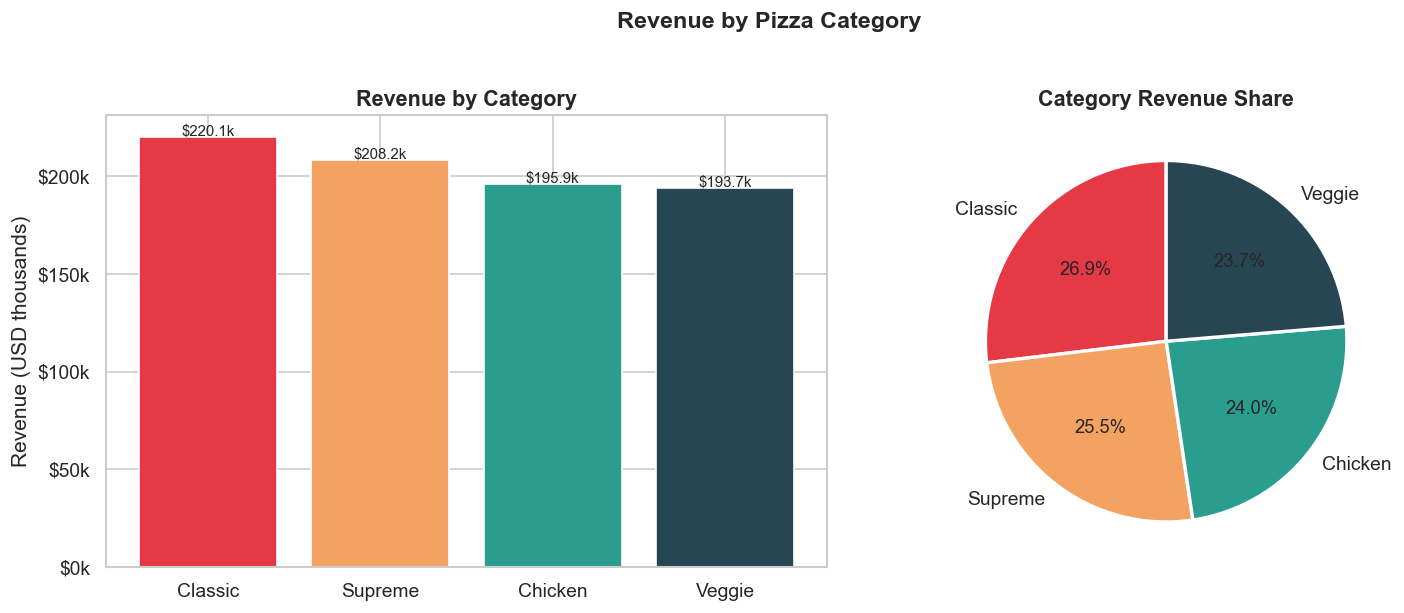

In [ ]:
# Chart: Revenue by Category (Bar + Pie) 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

ax1.bar(cat_rev.index, cat_rev.values/1000, color=PALETTE[:4], edgecolor='white')
ax1.set_title('Revenue by Category', fontsize=13, fontweight='bold')
ax1.set_ylabel('Revenue (USD thousands)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
for i, (c, v) in enumerate(zip(cat_rev.index, cat_rev.values)):
    ax1.text(i, v/1000 + 1, f'${v/1000:.1f}k', ha='center', fontsize=9)

wedges, texts, autotexts = ax2.pie(
    cat_rev.values, labels=cat_rev.index,
    autopct='%1.1f%%', colors=PALETTE[:4],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts: at.set_fontsize(11)
ax2.set_title('Category Revenue Share', fontsize=13, fontweight='bold')

plt.suptitle('Revenue by Pizza Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

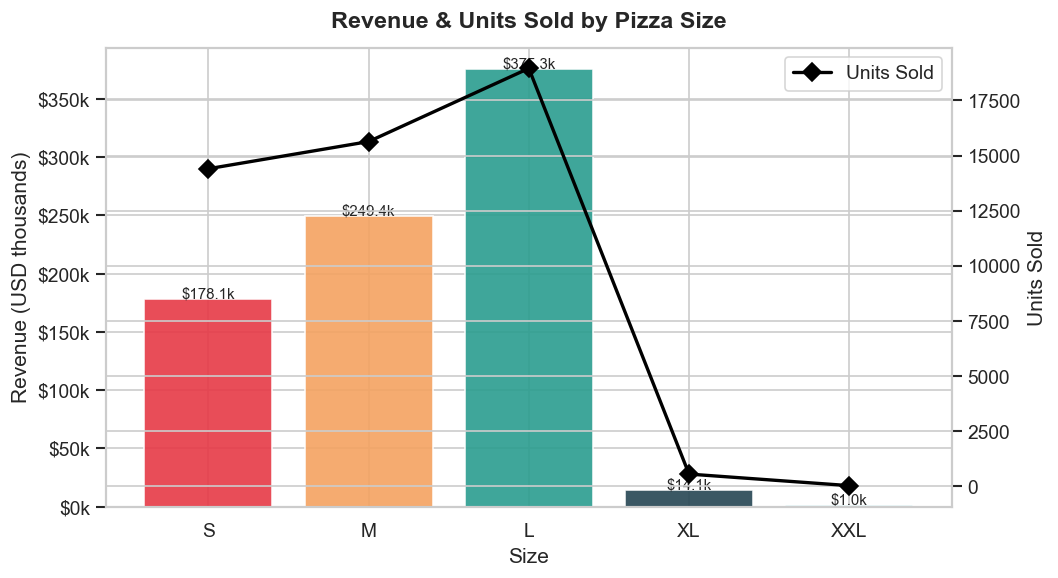

In [ ]:
# Chart: Revenue by Size (Bar + Line)
fig, ax = plt.subplots(figsize=(9, 5))

size_rev = df.groupby('size')['revenue'].sum().reindex(['S','M','L','XL','XXL'])
size_qty = df.groupby('size')['quantity'].sum().reindex(['S','M','L','XL','XXL'])

bars = ax.bar(['S','M','L','XL','XXL'], size_rev.values/1000,
              color=PALETTE[:5], edgecolor='white', alpha=0.9)
ax2_twin = ax.twinx()
ax2_twin.plot(['S','M','L','XL','XXL'], size_qty.values, 'D-', color='black', ms=8, lw=2,
              label='Units Sold')

ax.set_title('Revenue & Units Sold by Pizza Size', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Size'); ax.set_ylabel('Revenue (USD thousands)')
ax2_twin.set_ylabel('Units Sold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
for i, (s, v) in enumerate(zip(['S','M','L','XL','XXL'], size_rev.values)):
    ax.text(i, v/1000 + 1, f'${v/1000:.1f}k', ha='center', fontsize=9)
ax2_twin.legend(loc='upper right')
plt.tight_layout()
plt.show()

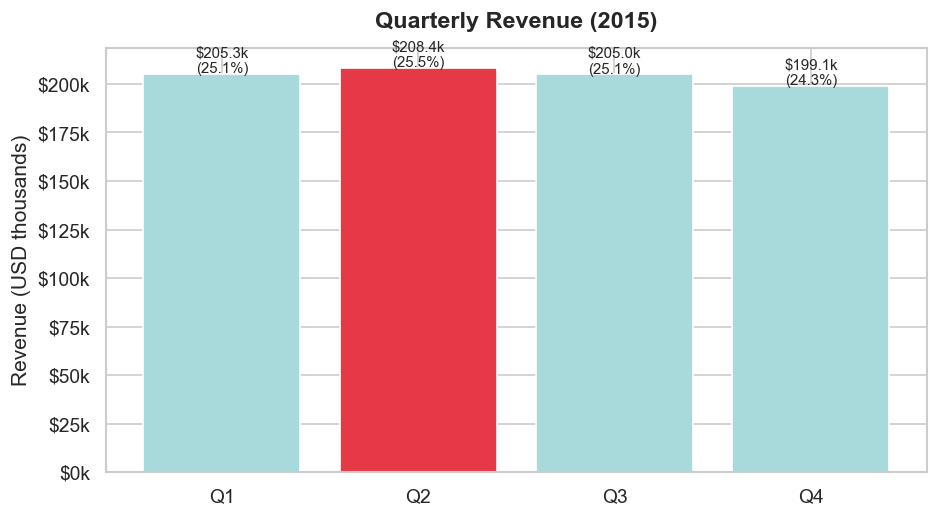

In [ ]:
# Chart: Quarterly Revenue 
fig, ax = plt.subplots(figsize=(8, 4.5))

q_rev = df.groupby('quarter')['revenue'].sum()
ax.bar([f'Q{q}' for q in q_rev.index], q_rev.values/1000,
       color=[PALETTE[0] if v == q_rev.max() else PALETTE[4] for v in q_rev.values],
       edgecolor='white')
ax.set_title('Quarterly Revenue (2015)', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Revenue (USD thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
for i, v in enumerate(q_rev.values):
    ax.text(i, v/1000 + 0.5, f'${v/1000:.1f}k\n({v/total_rev*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Insights Revenue

| Temuan | Detail |
|---|---|
| **Total Revenue** | **\$817,860** sepanjang 2015 |
| **Bulan terbaik** | **Juli** (\$72,558) — peak musim panas |
| **Bulan terlemah** | **Oktober** (\$64,028) — perlu investigasi |
| **Kategori terkuat** | **Classic** (\$220,053 / 26.9%) |
| **Distribusi merata** | Semua 4 kategori sangat berimbang (23–27%) — menu diversifikasi bagus |
| **Ukuran Large dominan** | Large menghasilkan **45.9%** total revenue |
| **XL & XXL sangat kecil** | Hanya <2% combined — kandidat untuk evaluasi ulang |

---
## 6. Product Performance Analysis <a id='6'></a>

In [ ]:
# Product-level aggregation 
product_perf = df.groupby(['name','category']).agg(
    total_qty    = ('quantity', 'sum'),
    total_revenue= ('revenue', 'sum'),
    avg_price    = ('price', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

print('Top 5 by Revenue:')
display(product_perf.head())

Top 5 by Revenue:


,name,category,total_qty,total_revenue,avg_price
30,The Thai Chicken Pizza,Chicken,2371,43434.25,18.286069
0,The Barbecue Chicken Pizza,Chicken,2432,42768.00,17.572934
4,The California Chicken Pizza,Chicken,2370,41409.50,17.448523
7,The Classic Deluxe Pizza,Classic,2453,38180.50,15.575952
26,The Spicy Italian Pizza,Supreme,1924,34831.25,18.104663


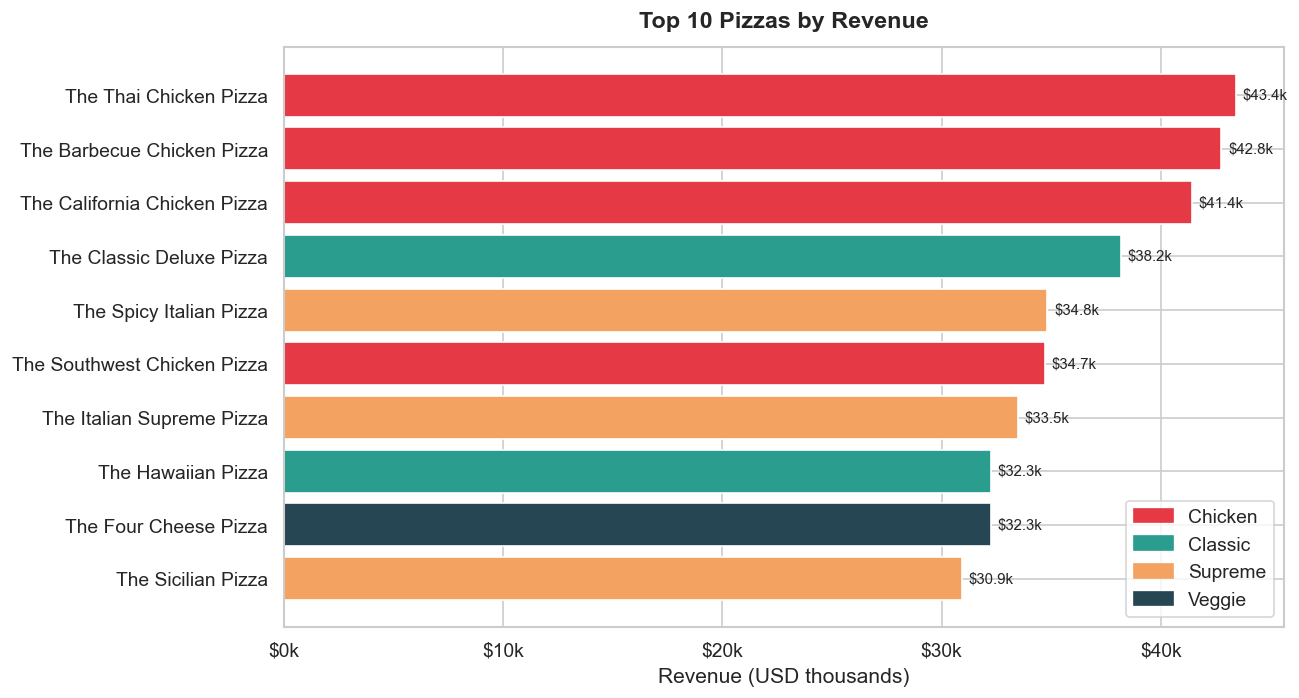

In [ ]:
# Chart: Top 10 Pizzas by Revenue 
fig, ax = plt.subplots(figsize=(11, 6))

top10 = product_perf.head(10)
bar_colors_t = [PALETTE[0] if cat == 'Chicken' else
                PALETTE[2] if cat == 'Classic' else
                PALETTE[1] if cat == 'Supreme' else PALETTE[3]
                for cat in top10['category']]

bars = ax.barh(top10['name'][::-1], top10['total_revenue'][::-1]/1000,
               color=bar_colors_t[::-1], edgecolor='white')
ax.set_title('Top 10 Pizzas by Revenue', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Revenue (USD thousands)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2, f'${w:.1f}k', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_els = [Patch(color=PALETTE[0], label='Chicken'),
              Patch(color=PALETTE[2], label='Classic'),
              Patch(color=PALETTE[1], label='Supreme'),
              Patch(color=PALETTE[3], label='Veggie')]
ax.legend(handles=legend_els, loc='lower right')
plt.tight_layout()
plt.show()

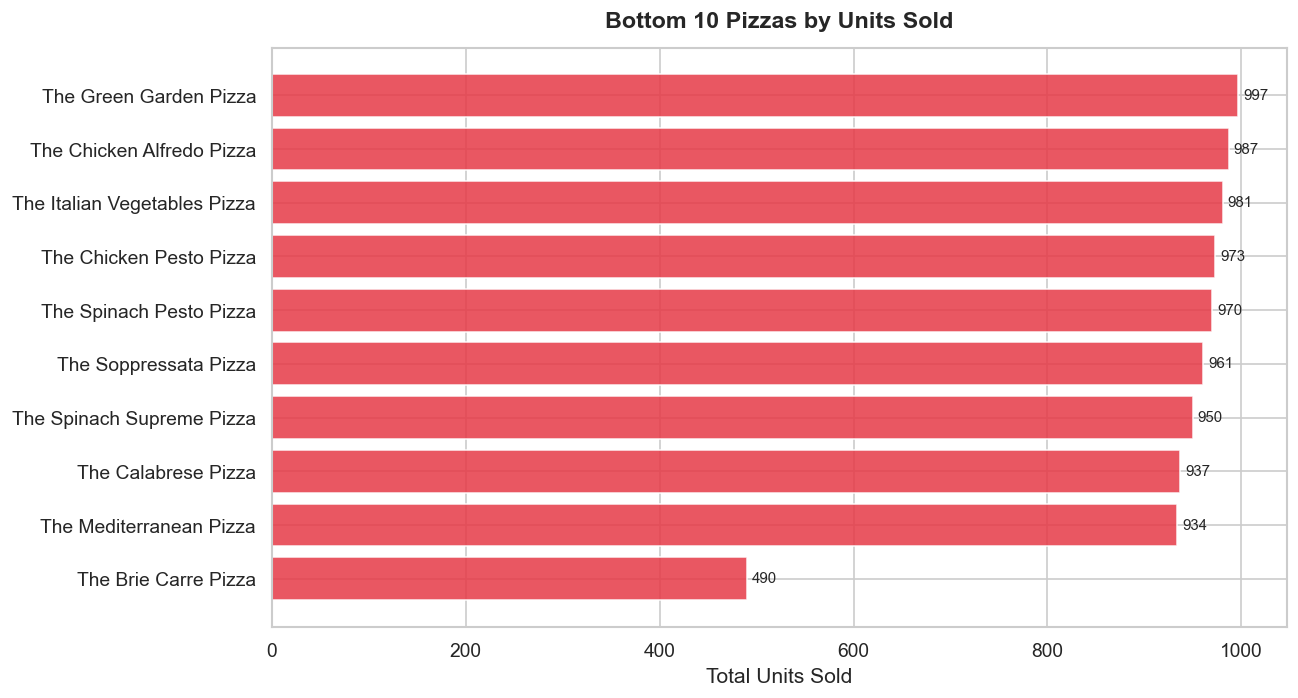

In [ ]:
# Chart: Bottom 10 Pizzas by Units Sold
fig, ax = plt.subplots(figsize=(11, 6))

bottom10 = product_perf.sort_values('total_qty').head(10)
ax.barh(bottom10['name'], bottom10['total_qty'],
        color='#E63946', edgecolor='white', alpha=0.85)
ax.set_title('Bottom 10 Pizzas by Units Sold', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Units Sold')
for i, (n, v) in enumerate(zip(bottom10['name'], bottom10['total_qty'])):
    ax.text(v + 5, i, str(int(v)), va='center', fontsize=9)
plt.tight_layout()
plt.show()

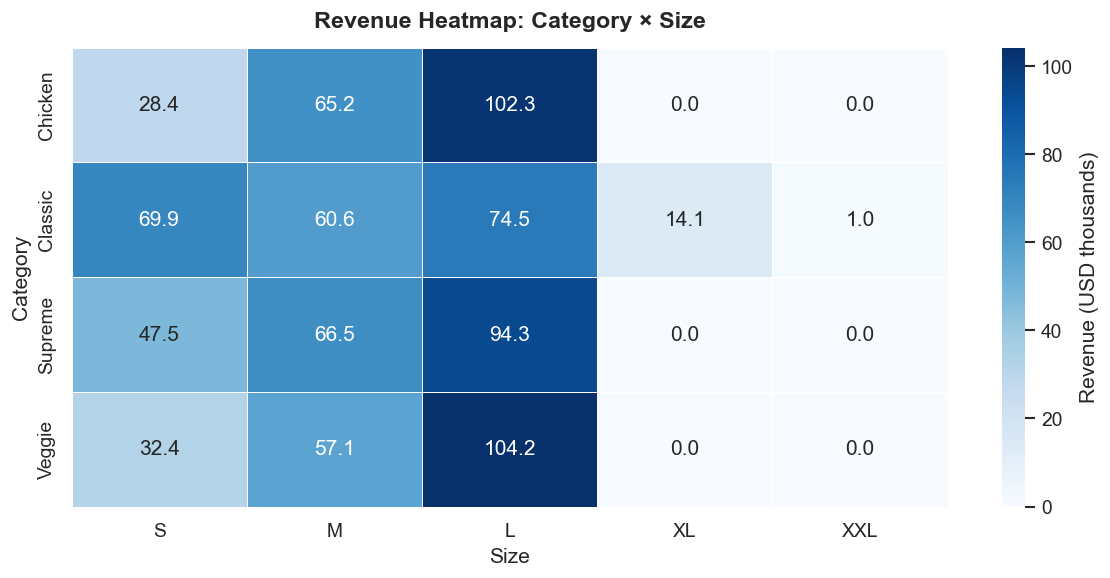

In [ ]:
# Chart: Heatmap Category × Size Revenue 
fig, ax = plt.subplots(figsize=(10, 5))

cat_size = df.groupby(['category','size'])['revenue'].sum().unstack(fill_value=0)
cat_size = cat_size.reindex(columns=['S','M','L','XL','XXL'])

sns.heatmap(cat_size/1000, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Revenue (USD thousands)'})
ax.set_title('Revenue Heatmap: Category × Size', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Size'); ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

### Insights Product Performance

| Temuan | Detail |
|---|---|
| **Pizza terlaris** | **The Thai Chicken Pizza** (\$43,434 revenue) |
| **3 dari top 5 = Chicken** | Kategori Chicken adalah premium revenue driver |
| **Pizza paling sedikit terjual** | **The Brie Carre Pizza** — hanya 490 unit (5× lebih sedikit dari #1) |
| **Large Classic & Supreme** | Kombinasi paling menghasilkan revenue di heatmap |
| **XL & XXL** | Hampir tidak berkontribusi di semua kategori |
| **Rekomendasi** | Evaluasi pizza bottom-5 untuk dikurangi / digantikan produk baru |

---
## 7. Sales Analysis <a id='7'></a>

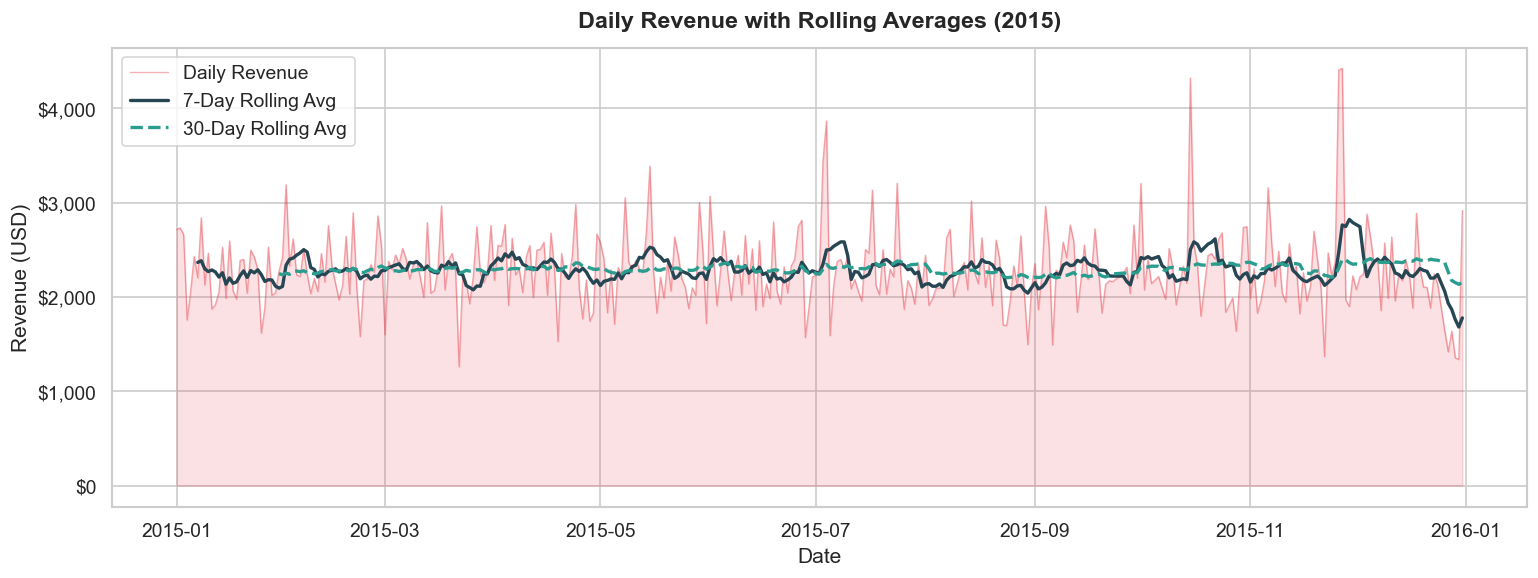

In [ ]:
# Chart: Daily Revenue with Rolling Average 
fig, ax = plt.subplots(figsize=(13, 5))

daily_rev = df.groupby('date')['revenue'].sum()
rolling7  = daily_rev.rolling(7).mean()
rolling30 = daily_rev.rolling(30).mean()

ax.fill_between(daily_rev.index, daily_rev.values, alpha=0.15, color=PALETTE[0])
ax.plot(daily_rev.index, daily_rev.values, color=PALETTE[0], lw=0.8, alpha=0.4, label='Daily Revenue')
ax.plot(rolling7.index, rolling7.values, color=PALETTE[3], lw=2, label='7-Day Rolling Avg')
ax.plot(rolling30.index, rolling30.values, color=PALETTE[2], lw=2, linestyle='--', label='30-Day Rolling Avg')

ax.set_title('Daily Revenue with Rolling Averages (2015)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date'); ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

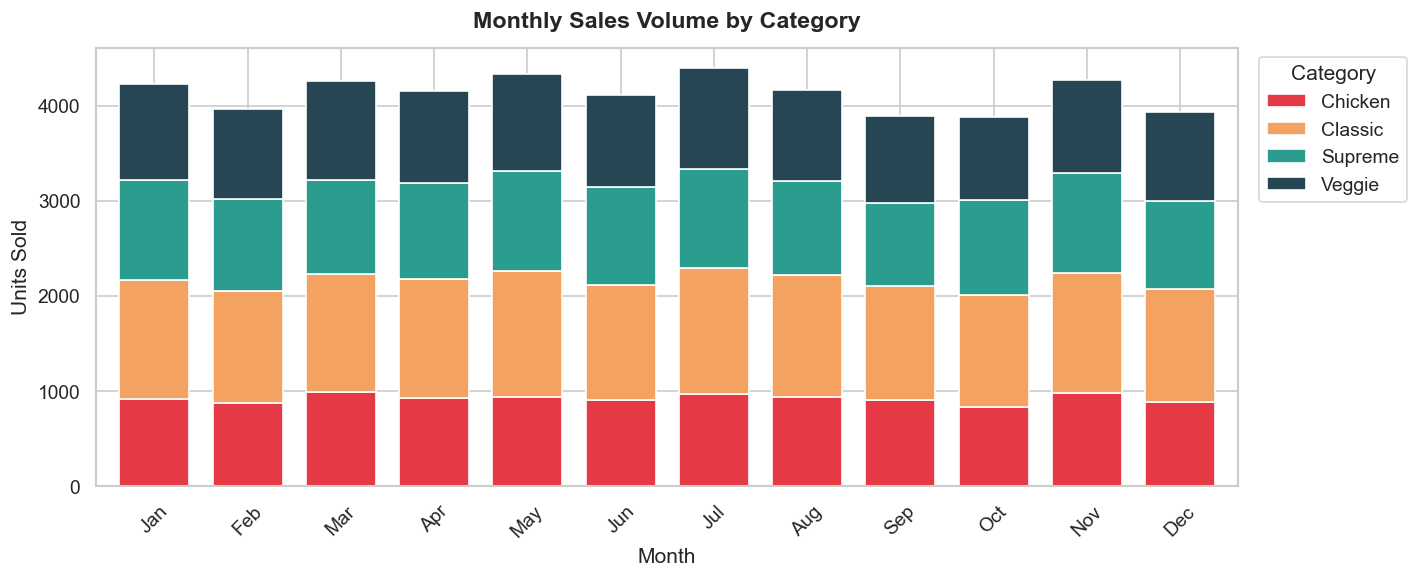

In [37]:
# ── Chart: Monthly Sales Volume by Category (Stacked Bar) ────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

month_cat = df.groupby(['month','month_name','category'])['quantity'].sum().reset_index()
month_cat['month_name'] = pd.Categorical(month_cat['month_name'], categories=month_order, ordered=True)
pivot_mc = month_cat.pivot_table(index='month_name', columns='category', values='quantity', aggfunc='sum')
pivot_mc = pivot_mc.reindex(month_order)

pivot_mc.plot(kind='bar', stacked=True, ax=ax, color=PALETTE[:4],
              edgecolor='white', width=0.75)
ax.set_title('Monthly Sales Volume by Category', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('Units Sold')
ax.legend(title='Category', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

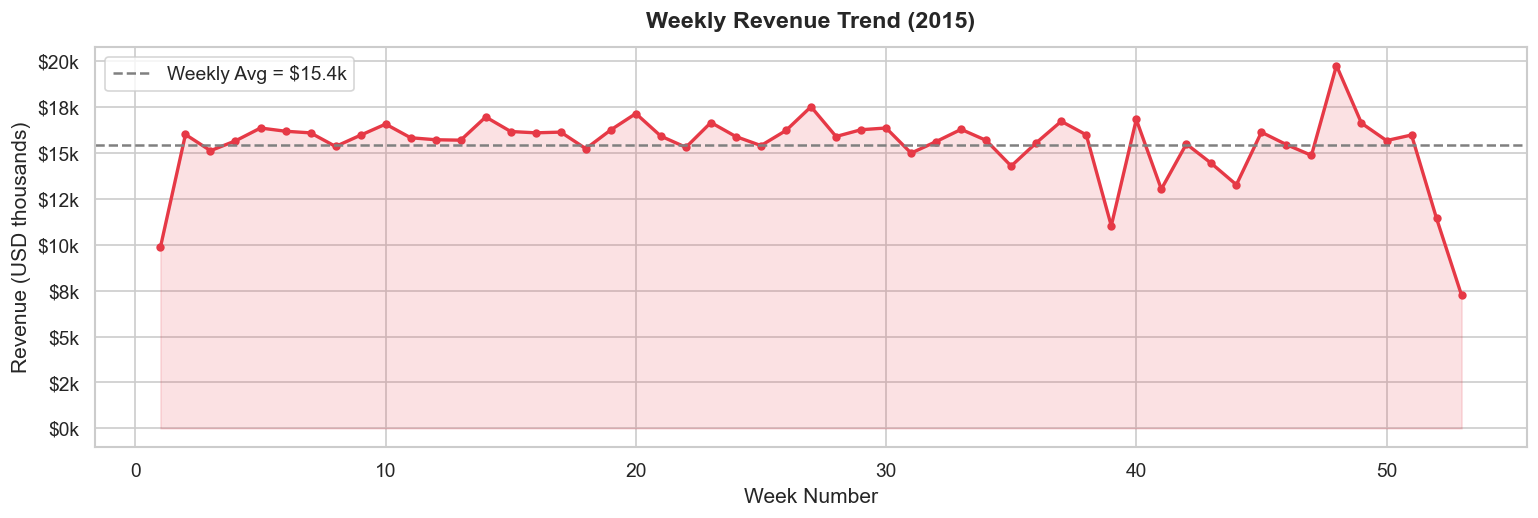

In [ ]:
# Chart: Weekly Revenue Trend 
fig, ax = plt.subplots(figsize=(13, 4.5))

weekly_rev = df.groupby('week')['revenue'].sum()
ax.plot(weekly_rev.index, weekly_rev.values/1000, color=PALETTE[0], lw=2, marker='o', ms=4)
ax.fill_between(weekly_rev.index, weekly_rev.values/1000, alpha=0.15, color=PALETTE[0])
ax.axhline(weekly_rev.mean()/1000, color='gray', lw=1.5, linestyle='--',
           label=f'Weekly Avg = ${weekly_rev.mean()/1000:.1f}k')

ax.set_title('Weekly Revenue Trend (2015)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Week Number'); ax.set_ylabel('Revenue (USD thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

### Insights Sales

| Temuan | Detail |
|---|---|
| **Tren stabil** | Revenue harian konsisten sepanjang tahun tanpa drop drastis |
| **Summer peak** | Mei–Juli menunjukkan sedikit kenaikan yang konsisten |
| **Q4 melemah** | Oktober–Desember sedikit di bawah rata-rata — butuh strategi promosi |
| **Semua kategori stabil** | Classic dan Supreme konsisten tiap bulan |
| **Weekly cycles** | Terdapat pola mingguan yang jelas — puncak di akhir minggu, turun di awal minggu |

🍕 Pizza Sales 2015 — Insight, Kesimpulan & Rekomendasi Bisnis

Insight Utama
1. Pelanggan Datang di Waktu yang Sangat Spesifik
Data menunjukkan pola yang sangat teratur: ada dua gelombang kedatangan pelanggan setiap harinya. Gelombang pertama terjadi tepat di jam makan siang (puncak di jam 12:00 dengan 2.520 order), dan gelombang kedua muncul saat jam pulang kerja (jam 17:00–18:00 dengan sekitar 2.336–2.399 order). Di luar dua jendela waktu ini, volume order turun cukup signifikan.
Yang menarik, pola ini konsisten hampir setiap hari — artinya perilaku pelanggan sangat dapat diprediksi, dan ini adalah aset yang bisa dimanfaatkan untuk perencanaan operasional maupun promosi.
Dari sisi hari, Jumat adalah hari paling sibuk dengan total 3.538 order — selisihnya mencapai 34,6% dibanding hari paling sepi (Minggu). Kombinasi Jumat dan Sabtu malam menjadi "golden window" bisnis setiap minggunya.

2. Ukuran Large Memimpin, Tapi Medium Tak Kalah Penting
Dari sisi revenue, ukuran Large (L) menyumbang sekitar 45,9% dari total pendapatan — hampir separuh bisnis ini bergantung pada satu ukuran saja. Ini mencerminkan bahwa pelanggan cenderung membeli pizza untuk berbagi, bukan sekadar konsumsi pribadi.
Namun ukuran Medium (M) tidak bisa diabaikan — kontribusinya sekitar 30% dan menjadi pilihan utama pelanggan yang datang berdua atau berkelompok kecil. Sementara ukuran Small (S) lebih diminati untuk konsumsi sendiri atau sebagai pelengkap order.
Di sisi lain, XL dan XXL hampir tidak bergerak — kontribusi keduanya terhadap total revenue tidak sampai 2%. Ini adalah sinyal jelas bahwa ukuran tersebut tidak mendapat respons pasar yang berarti.

3. Kategori Chicken Mendominasi Revenue Per Produk
Jika dilihat per item, tiga dari lima pizza dengan revenue tertinggi berasal dari kategori Chicken:

🥇 The Thai Chicken Pizza — $43.434
🥈 The Barbecue Chicken Pizza — $42.768
🥉 The California Chicken Pizza — $41.410

Meski secara total kategori Classic masih yang teratas ($220.053 / 26,9%), ini karena Classic memiliki lebih banyak varian. Secara per-produk individual, Chicken jelas unggul dan harga jualnya yang sedikit lebih tinggi membuat margin per transaksinya lebih menarik.
Di ujung yang berlawanan, The Brie Carre Pizza hanya terjual 490 unit sepanjang satu tahun penuh. Itu berarti rata-rata kurang dari 2 porsi per hari jauh di bawah pizza terlaris yang bisa tembus lebih dari 6 porsi/hari.

4. Revenue Stabil Sepanjang Tahun, Tapi Ada Pola Musiman
Total revenue 2015 mencapai $817.860, dengan rata-rata bulanan $68.155. Tren ini relatif datar dan stabil tidak ada bulan yang anjlok drastis, yang menunjukkan fondasi bisnis yang cukup sehat.
Namun bila ditelusuri lebih dalam, ada pola musiman ringan yang konsisten:

Mei–Juli (Q3) adalah periode terkuat dengan puncak di bulan Juli ($72.558)
Oktober–Desember (Q4) cenderung lebih lemah, dengan titik terendah di Oktober ($64.028)

Selisih antara bulan terbaik dan terburuk mencapai sekitar $8.500 — tidak dramatis, tapi cukup signifikan jika dibiarkan tanpa intervensi.

5. Rata-rata Order Masih Punya Ruang untuk Tumbuh
Rata-rata setiap order menghasilkan $38.31 dengan 2,32 item. Sebanyak 75% order hanya berisi maksimal 3 item artinya sebagian besar pelanggan tidak membeli banyak sekaligus.
Ini sebenarnya bukan masalah, melainkan peluang. Sedikit saja dorongan untuk menambah satu item lagi per transaksi bisa berdampak cukup besar terhadap total revenue tahunan.

KESIMPULAN 

Secara keseluruhan, Pizza Company menjalankan bisnis yang stabil, terprediksi, dan terdiversifikasi dengan baik. Tidak ada satu produk atau bulan yang menjadi satu-satunya penopang — empat kategori pizza berkontribusi cukup merata (masing-masing antara 23–27%).
Namun ada beberapa ketidakseimbangan yang perlu diperhatikan:

Ketergantungan tinggi pada ukuran Large hampir separuh revenue berasal dari satu segmen ukuran. Jika permintaan L berubah, dampaknya langsung terasa.
Beberapa produk "hidup segan mati tak mau" pizza dengan penjualan sangat rendah seperti The Brie Carre tetap membutuhkan bahan baku dan slot menu, tanpa memberikan kontribusi yang sepadan.
Momentum Q4 yang melemah tanpa strategi aktif, pola penurunan di akhir tahun akan terus berulang.
Potensi upsell yang belum digarap maksimal 75% order ≤ 3 item menunjukkan ada ruang besar untuk mendorong nilai transaksi lebih tinggi.